In [ ]:
import os
import pandas as pd

# Define path
base_path = 'archive'
csv_path = os.path.join(base_path, 'df.csv')

# load JUST the CSV with only 100 rows
try:
    df = pd.read_csv(csv_path, nrows=100)
    print("CSV loaded successfully!")
    
    # Step 2: Check the directory content manually
    if os.path.exists(base_path):
        print(f"Contents of {base_path}: {os.listdir(base_path)}")
    else:
        print(f"Error: The folder '{base_path}' was not found in your current directory.")
        print(f"Current Directory: {os.getcwd()}")
        
    display(df.head())
except Exception as e:
    print(f"An error occurred: {e}")

CSV loaded successfully!
Contents of archive: ['.DS_Store', 'images', 'df.csv']


,ImageID,Source,LabelName,Confidence,XMin,XMax,YMin,YMax,IsOccluded,IsTruncated,...,IsDepiction,IsInside,XClick1X,XClick2X,XClick3X,XClick4X,XClick1Y,XClick2Y,XClick3Y,XClick4Y
0,0000599864fd15b3,xclick,Bus,1,0.343750,0.908750,0.156162,0.650047,1,0,...,0,0,0.421875,0.343750,0.795000,0.908750,0.156162,0.512700,0.650047,0.457197
1,00006bdb1eb5cd74,xclick,Truck,1,0.276667,0.697500,0.141604,0.437343,1,0,...,0,0,0.299167,0.276667,0.697500,0.659167,0.141604,0.241855,0.352130,0.437343
2,00006bdb1eb5cd74,xclick,Truck,1,0.702500,0.999167,0.204261,0.409774,1,1,...,0,0,0.849167,0.702500,0.906667,0.999167,0.204261,0.398496,0.409774,0.295739
3,00010bf498b64bab,xclick,Bus,1,0.156250,0.371250,0.269188,0.705228,0,0,...,0,0,0.274375,0.371250,0.311875,0.156250,0.269188,0.493882,0.705228,0.521691
4,00013f14dd4e168f,xclick,Bus,1,0.287500,0.999375,0.194184,0.999062,0,1,...,0,0,0.920000,0.999375,0.648750,0.287500,0.194184,0.303940,0.999062,0.523452


In [55]:
import cv2
import numpy as np
import os
from skimage.transform import resize
from skimage.feature import hog  # New library for feature extraction

# 1. IoU Function
def get_iou(bb1, bb2):
    x_left = max(bb1['x1'], bb2['x1'])
    y_top = max(bb1['y1'], bb2['y1'])
    x_right = min(bb1['x2'], bb2['x2'])
    y_bottom = min(bb1['y2'], bb2['y2'])
    if x_right < x_left or y_bottom < y_top: return 0.0
    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    bb1_area = (bb1['x2'] - bb1['x1']) * (bb1['y2'] - bb1['y1'])
    bb2_area = (bb2['x2'] - bb2['x1']) * (bb2['y2'] - bb2['y1'])
    return intersection_area / float(bb1_area + bb2_area - intersection_area)

# 2. Selective Search Setup
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()

X_patches = []
y_labels = []

img_folder = os.path.join('archive', 'images', 'images')
# Increased to 100 images for better diversity
sample_ids = df['ImageID'].unique()[:100] 

print("Extracting HOG patches (this will take a few minutes)...")

for img_id in sample_ids:
    img_path = os.path.join(img_folder, img_id + '.jpg')
    image = cv2.imread(img_path)
    if image is None: continue
    
    h, w, _ = image.shape
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # HOG usually works on grayscale
    gt_boxes = df[df['ImageID'] == img_id]
    
    ss.setBaseImage(image)
    ss.switchToSelectiveSearchFast()
    rects = ss.process()
    
    p, n = 0, 0
    for (x, y_p, w_r, h_r) in rects:
        if p > 10 and n > 10: break 
        
        prop_box = {'x1': x, 'y1': y_p, 'x2': x + w_r, 'y2': y_p + h_r}
        best_iou = 0
        label = 0 
        
        for _, row in gt_boxes.iterrows():
            gt_box = {'x1': row['XMin']*w, 'y1': row['YMin']*h, 'x2': row['XMax']*w, 'y2': row['YMax']*h}
            iou = get_iou(prop_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                label = 1 if row['LabelName'] == 'Bus' else 2
        
        if (best_iou > 0.5 and p <= 10) or (best_iou < 0.1 and n <= 10):
            # Extract ROI from grayscale image for HOG
            roi = img_gray[y_p:y_p+h_r, x:x+w_r]
            roi_resized = cv2.resize(roi, (64, 64))
            
            # --- HOG FEATURE EXTRACTION ---
            # This captures the 'shape' of the bus/truck
            features = hog(roi_resized, orientations=9, pixels_per_cell=(8, 8),
                           cells_per_block=(2, 2), visualize=False)
            
            X_patches.append(features)
            y_labels.append(label if best_iou > 0.5 else 0)
            
            if best_iou > 0.5: p += 1
            else: n += 1

X_patches = np.array(X_patches)
y_labels = np.array(y_labels)
print(f"Done! Created {len(X_patches)} HOG training patches.")

Extracting HOG patches (this will take a few minutes)...
Done! Created 1397 HOG training patches.


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Split the data into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_patches, y_labels, test_size=0.2, random_state=42
)

print(f"Training on {len(X_train)} samples...")

# 2. Initialize the SVM Classifier
# We use 'rbf' kernel for better handling of image data patterns
model = SVC(kernel='rbf', C=10, gamma='scale', probability=True)

# 3. The .fit() method 
model.fit(X_train, y_train)

# 4. Evaluation
y_pred = model.predict(X_test)

print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Background', 'Bus', 'Truck']))

Training on 1117 samples...

--- Model Evaluation ---
Accuracy: 84.64%

Classification Report:
              precision    recall  f1-score   support

  Background       0.83      0.96      0.89       134
         Bus       0.90      0.80      0.85        69
       Truck       0.83      0.70      0.76        77

    accuracy                           0.85       280
   macro avg       0.85      0.82      0.83       280
weighted avg       0.85      0.85      0.84       280



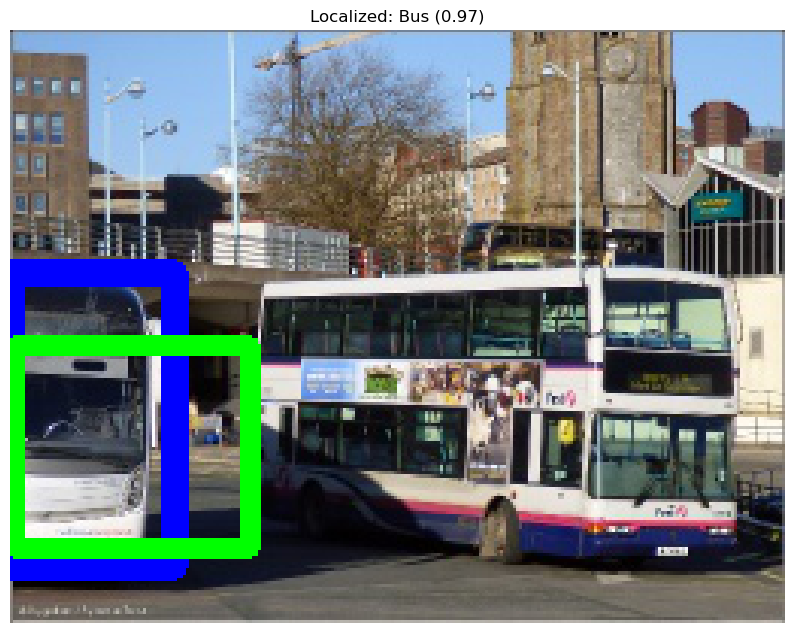

In [ ]:
def localize_rcnn(img_id):
    # 1. Loading the full image
    img_path = os.path.join(img_folder, img_id + '.jpg')
    image = cv2.imread(img_path)
    if image is None: 
        print("Image not found.")
        return
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # HOG needs grayscale
    h, w, _ = image.shape

    # 2. Geting the Ground Truth (GT)
    gt_data = df[df['ImageID'] == img_id].iloc[0]
    gt_label = gt_data['LabelName']
    gt_coords = [
        int(gt_data['XMin'] * w), int(gt_data['YMin'] * h),
        int(gt_data['XMax'] * w), int(gt_data['YMax'] * h)
    ]

    # 3. R-CNN Localization: Run Selective Search
    ss.setBaseImage(image)
    ss.switchToSelectiveSearchFast()
    rects = ss.process()

    best_box = None
    max_conf = 0
    pred_label = ""

    # Test candidate boxes
    for (rx, ry, rw, rh) in rects[:500]: # Increased search depth for better accuracy
        # Extract ROI and resize
        roi = img_gray[ry:ry+rh, rx:rx+rw]
        roi_resized = cv2.resize(roi, (64, 64))
        
        # --- IMPORTANT: Convert patch to HOG features (matching Cell 2) ---
        features = hog(roi_resized, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), visualize=False).reshape(1, -1)
        
        # 4. SVM Prediction
        probs = model.predict_proba(features)[0]
        label_idx = np.argmax(probs)
        conf = probs[label_idx]

        # Only select if it's a Bus (1) or Truck (2) and confidence is high
        if label_idx != 0 and conf > max_conf:
            max_conf = conf
            best_box = (rx, ry, rx+rw, ry+rh)
            pred_label = label_map[label_idx]

    # 5. Visualization
    plt.figure(figsize=(10, 10))
    # Ground Truth (Blue)
    cv2.rectangle(img_rgb, (gt_coords[0], gt_coords[1]), (gt_coords[2], gt_coords[3]), (0, 0, 255), 8)
    # Prediction (Green)
    if best_box:
        cv2.rectangle(img_rgb, (best_box[0], best_box[1]), (best_box[2], best_box[3]), (0, 255, 0), 6)
        plt.title(f"Localized: {pred_label} ({max_conf:.2f})")
    else:
        plt.title("No object detected with high confidence")

    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

# Run the updated localization
localize_rcnn(df.iloc[41]['ImageID'])